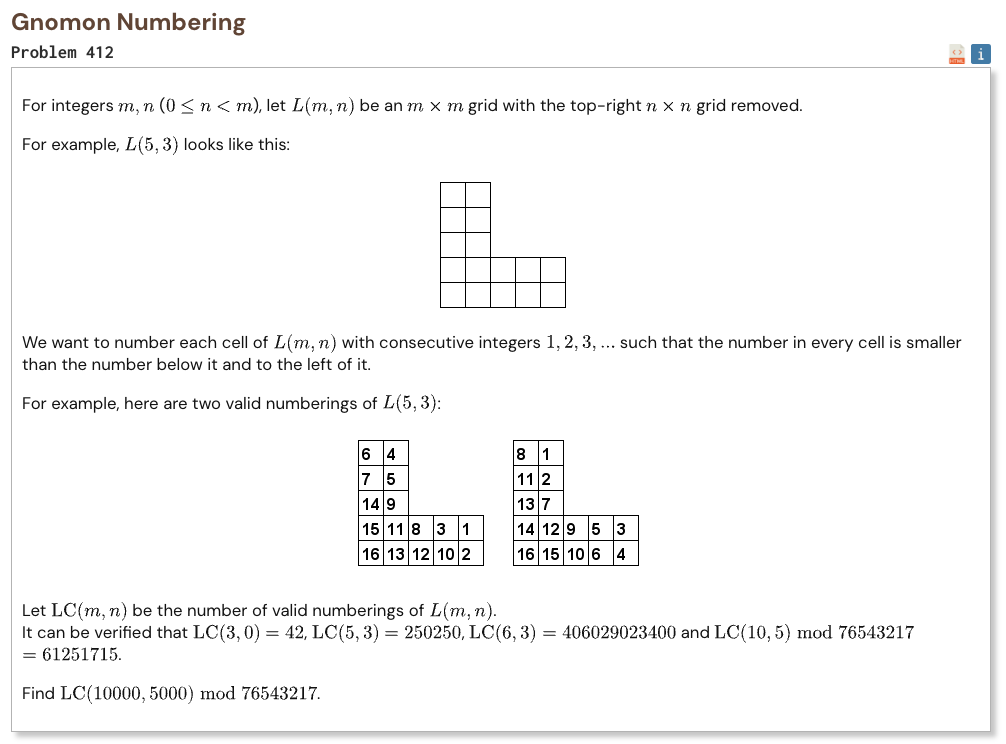

## Initial approach

-   rotate the board mentally so it becomes a standard Young diagram
-   use the hook length rule to count all valid numberings
-   group the hook lengths by rows instead of visiting every cell
-   calculate factorials and inverse factorials under the required modulus
-   use Wilsons theorem to avoid computing a factorial with seventy five million terms
-   combine the numerator and hook products using modular division
-   the calculation only needs a few million simple operations

In [1]:
MOD = 76543217

def factorial_mod(n):
    remaining = MOD - 1 - n

    if n <= remaining:
        product = 1
        for value in range(2, n + 1):
            product = product * value % MOD
        return product

    product = 1
    for value in range(n + 1, MOD):
        product = product * value % MOD

    return -pow(product, MOD - 2, MOD) % MOD

def gnomon_numberings(m, n):
    short_side = m - n
    cells = m * m - n * n
    limit = 2 * m

    factorial = [1] * (limit + 1)

    for value in range(1, limit + 1):
        factorial[value] = factorial[value - 1] * value % MOD

    inverse_factorial = [1] * (limit + 1)
    inverse_factorial[limit] = pow(factorial[limit], MOD - 2, MOD)

    for value in range(limit, 0, -1):
        inverse_factorial[value - 1] = (
            inverse_factorial[value] * value % MOD
        )

    hook_product = 1

    for row in range(short_side):
        square_hooks = (
            factorial[2 * m - row - 1]
            * inverse_factorial[2 * m - row - short_side - 1]
            % MOD
        )

        arm_hooks = (
            factorial[m - row - 1]
            * inverse_factorial[m - row - n - 1]
            % MOD
        )

        hook_product = hook_product * square_hooks % MOD
        hook_product = hook_product * arm_hooks % MOD
        hook_product = hook_product * arm_hooks % MOD

    numerator = factorial_mod(cells)
    return numerator * pow(hook_product, MOD - 2, MOD) % MOD

In [2]:
%%time

result = gnomon_numberings(10000, 5000)
print("Result:", result)

Result: 38788800
CPU times: user 64.6 ms, sys: 1.39 ms, total: 65.9 ms
Wall time: 65.6 ms
